In [1]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
import torch
from numpy import pi, exp, conj, min, argmin, unravel_index

In [4]:
def hl2_prime(n, z):
    return (n / z) * hankel2(n, z) - hankel2(n + 1, z) # derivative for hankel function of second kind
def hl1_prime(n, z):
    return (n / z) * hankel1(n, z) - hankel1(n + 1, z) # derivative for hankel function of first kind
def hl1_asymptotic(n, z):
    #return sqrt(2/(pi*z))*np.exp(1j*(z-pi/4))*(-1j)**n
    return sqrt(1/(pi*z))*(1-1j)*exp(1j*z)*(-1j)**n
def hl2_asymptotic(n, z):
    return conj(hl1_asymptotic(n, z)) # Note that z has to be real 

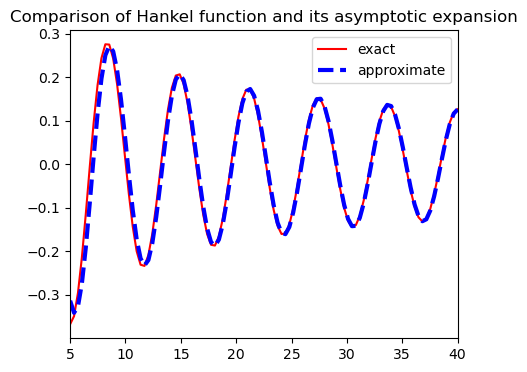

In [23]:
l = 2
x = linspace(5, 40, 100, endpoint=True)
hankel_exact = hankel2(l, x)
hankel_approximate = hl2_asymptotic(l, x)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, hankel_exact.imag, color="red", label = "exact")
ax.plot(x, hankel_approximate.imag, linestyle="dashed", linewidth=3, color="blue", label="approximate")
ax.set_xlim(5, 40);
ax.set_title("Comparison of Hankel function and its asymptotic expansion")
ax.legend();

### Coherent perfect absorption through finite surface impedance (large kR first)

In [32]:
M = 10000
epsilon = 2
sabs_odd_array = zeros((5, M))
sabs_even_array = zeros((5, M))
Z_s = -1 # Impedance of the surface layer (minus inverse of surface conductivity) in units of 1/c*epsilon_0
x = linspace(999, 1100, M) # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

n = 3
l_odd_array = linspace(1, 2*n + 1, n+1)
for (l_indx, l_float) in enumerate(l_odd_array):
    l = int(l_float)
    lhs_num = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
    rhs_num =  jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl2_prime(l, x)

    lhs_denom =  jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl1_prime(l, x)
    rhs_denom = sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
    s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)
    sabs_odd_array[l_indx, :] = abs(s)**2
    
n = 3
l_even_array = linspace(0, 2*n, n+1)
for (l_indx, l_float) in enumerate(l_even_array):
    l = int(l_float)
    lhs_num = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
    rhs_num =  jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl2_prime(l, x)

    lhs_denom =  jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl1_prime(l, x)
    rhs_denom = sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
    s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)
    sabs_even_array[l_indx, :] = abs(s)**2

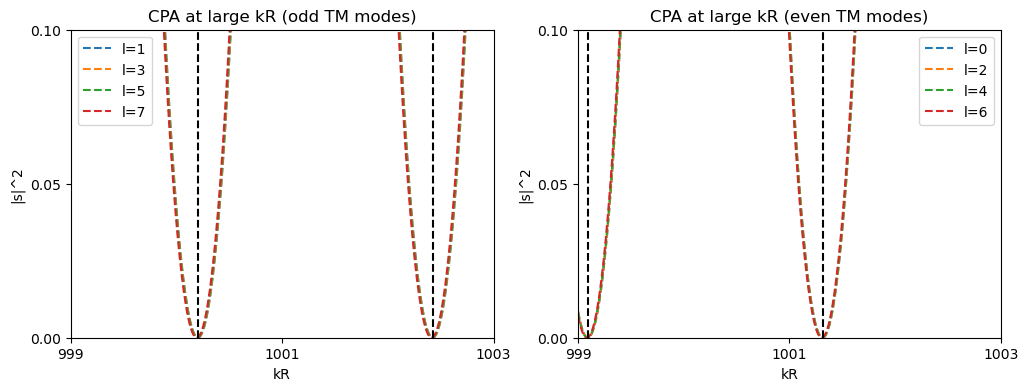

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for (l_indx, l) in enumerate(l_odd_array):
    ax1.plot(x, sabs_odd_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")

ax1.vlines([pi/4/sqrt(epsilon)]+ pi * linspace(1, 1000, 1000)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax1.set_ylim(0, 0.1)
ax1.set_xlim(999, 1003)
ax1.set_yticks([0, 0.05, 0.1])
ax1.set_xticks([999, 1001, 1003])
ax1.set_title("CPA at large kR (odd TM modes)")
ax1.set_xlabel("kR")
ax1.set_ylabel("|s|^2");
ax1.legend()

for (l_indx, l) in enumerate(l_even_array):
    ax2.plot(x, sabs_even_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax2.set_ylim(0, 0.1)
ax2.vlines([-pi/4/sqrt(epsilon)]+ pi * linspace(1, 1000, 1000)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax2.set_xlim(999, 1003)
ax2.set_yticks([0, 0.05, 0.1])
ax2.set_xticks([999, 1001, 1003])
ax2.set_title("CPA at large kR (even TM modes)")
ax2.set_xlabel("kR");
ax2.legend();
ax2.set_ylabel("|s|^2");

### Now we do the same for TE modes

In [35]:
M = 10000
epsilon = 2
sabs_odd_array = zeros((5, M))
sabs_even_array = zeros((5, M))
Z_s = -1 ## Impedance of the surface layer in units of 1/c*epsilon_0
x = linspace(999, 1003, M) # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

n = 3
l_odd_array = linspace(1, 2*n + 1, n+1)
for (l_indx, l_float) in enumerate(l_odd_array):
    l = int(l_float)
    lhs_num =  jv(l, y) * hl2_prime(l, x)
    rhs_num =  sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jv(l, y)* hankel2(l, x) 

    lhs_denom = jv(l, y) * hl1_prime(l, x)
    rhs_denom = sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jv(l, y)* hankel1(l, x) 
    s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)
    sabs_odd_array[l_indx, :] = abs(s)**2
    
n = 3
l_even_array = linspace(0, 2*n, n+1)
for (l_indx, l_float) in enumerate(l_even_array):
    l = int(l_float)
    lhs_num =  jv(l, y) * hl2_prime(l, x)
    rhs_num =  sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jv(l, y)* hankel2(l, x) 

    lhs_denom = jv(l, y) * hl1_prime(l, x)
    rhs_denom = sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jv(l, y)* hankel1(l, x) 
    s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)
    sabs_even_array[l_indx, :] = abs(s)**2

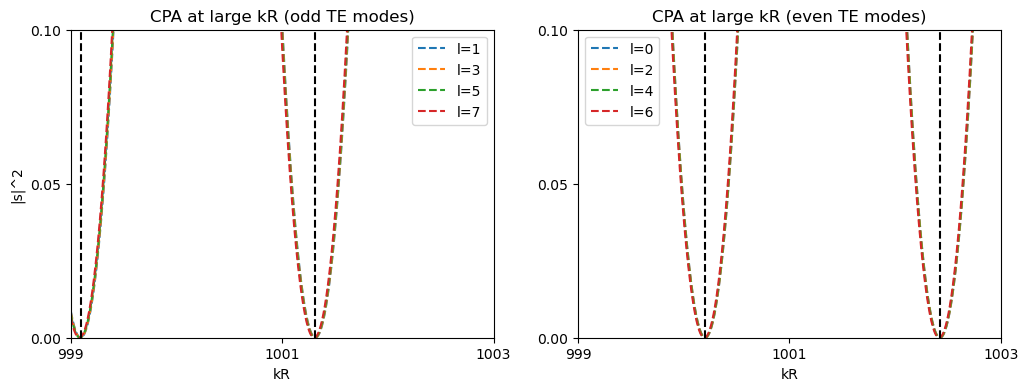

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for (l_indx, l) in enumerate(l_odd_array):
    ax1.plot(x, sabs_odd_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")

ax1.vlines([-pi/4/sqrt(epsilon)]+ pi * linspace(1, 1000, 1000)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax1.set_ylim(0, 0.1)
ax1.set_xlim(999, 1003)
ax1.set_yticks([0, 0.05, 0.1])
ax1.set_xticks([999, 1001, 1003])

ax1.set_xlabel("kR")
ax1.set_ylabel("|s|^2");
ax1.legend()
ax1.set_title("CPA at large kR (odd TE modes)")

for (l_indx, l) in enumerate(l_even_array):
    ax2.plot(x, sabs_even_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax2.set_ylim(0, 0.1)
ax2.vlines([pi/4/sqrt(epsilon)]+ pi * linspace(1, 1000, 1000)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax2.set_xlim(999, 1003)
ax2.set_yticks([0, 0.05, 0.1])
ax2.set_xticks([999, 1001, 1003])

ax2.set_xlabel("kR");
ax2.legend();
#ax2.set_ylabel("|s|^2");
ax2.set_title("CPA at large kR (even TE modes)");

### Now we look at subwavelength ($kR<1$)

### Note that the TM plasmon dispersion in the quasistatic limit obeys $(1+\varepsilon_m)x/l = -i\sigma(\omega)/c\varepsilon_0$. In the below, we define $g(\omega)=i/Z_sc\varepsilon_0=-i\sigma(\omega)/c\varepsilon_0$

In [38]:
epsilon_real = 1
l = 1

M = 1000
N = 5000
g_omega_center = x*(1+epsilon_real)/l # corresponds to quasistatic plasmon 
g_omegas = linspace(0.202, 0.203, M).reshape((M, 1)).repeat(N, 1)
epsilon_imaginary = linspace(0.014, 0.016, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real + 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

In [39]:
numerator = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)-jvp(l, y, 1) * hankel2(l, x) - g_omegas*jvp(l, y, 1)*hl2_prime(l, x)
denominator = jvp(l, y, 1) * hankel1(l, x) + g_omegas*jvp(l, y, 1)*hl1_prime(l, x) - sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
s = numerator/denominator

In [40]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  2.3215061964432818e-08


In [41]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [42]:
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", g_omegas[idxs])

CPA imepsilon:  0.015930786157231445  and CPA g(omega):  0.2026716716716717


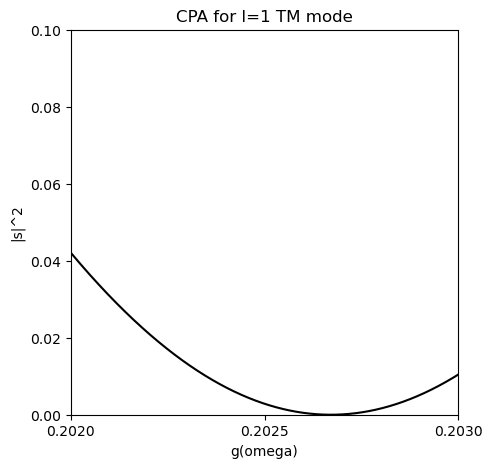

In [43]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 0.1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("g(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 TM mode");

### Now we try to achieve CPA by adding dissipation in the surface layer instead of dissipation in the bulk. I.e. the surface conductivity now has a real component.

In [48]:
epsilon_real = 1
l = 1

M = 1000
N = 5000
g_omega_center = x*(1+epsilon_real)/l # corresponds to quasistatic plasmon 
g_omegas = linspace(0.1, 0.3, M).reshape((M, 1)).repeat(N, 1)
g_omegas_imaginary = -linspace(0, 0.002, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real #+ 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

In [49]:
numerator = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)-jvp(l, y, 1) * hankel2(l, x) - (g_omegas+1j*g_omegas_imaginary)*jvp(l, y, 1)*hl2_prime(l, x)
denominator = jvp(l, y, 1) * hankel1(l, x) + (g_omegas+1j*g_omegas_imaginary)*jvp(l, y, 1)*hl1_prime(l, x) - sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
s = numerator/denominator

In [50]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  9.64759982275386e-05


In [51]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [52]:
print("CPA g_omega imaginary: ", g_omegas_imaginary[idxs], " and CPA g(omega) (real): ", g_omegas[idxs])

CPA g_omega imaginary:  -0.0016015203040608123  and CPA g(omega) (real):  0.2027027027027027


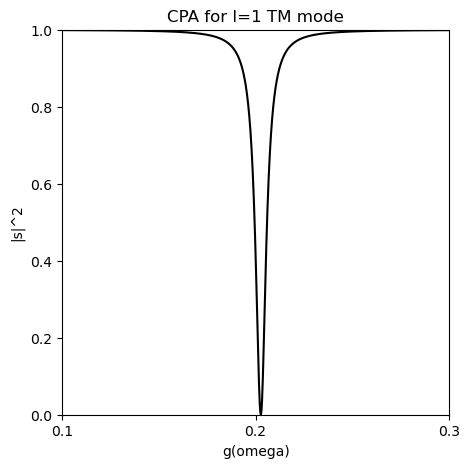

In [53]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("g(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 TM mode");

### Same as above but for l=2

In [54]:
epsilon_real = 12
l = 2
M = 1000
N = 5000
g_omegas = linspace(0.6562027927927928-1e-7, 0.6562027927927928+1e-7, M).reshape((M, 1)).repeat(N, 1)
epsilon_imaginary = linspace(0.000019, 0.000020, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real + 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder
g_omega_center = x*(1+epsilon_real)/l;

In [55]:
numerator = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)-jvp(l, y, 1) * hankel2(l, x) - g_omegas*jvp(l, y, 1)*hl2_prime(l, x)
denominator = jvp(l, y, 1) * hankel1(l, x) + g_omegas*jvp(l, y, 1)*hl1_prime(l, x)-sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
s = numerator/denominator

In [56]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  2.0401244383625403e-09


In [57]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [58]:
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", g_omegas[idxs])

CPA imepsilon:  1.9243448689737947e-05  and CPA g(omega):  0.6562027958958959


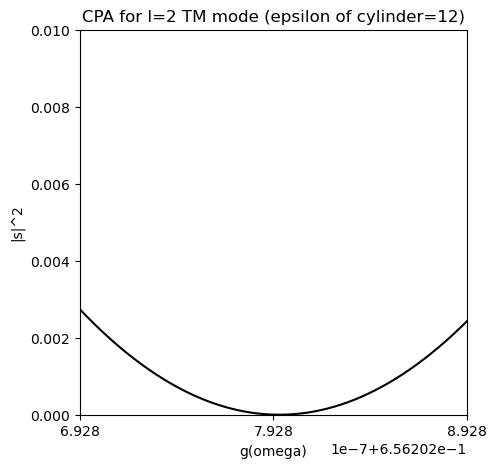

In [59]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 0.01)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("g(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 TM mode (epsilon of cylinder=12)");

### CPA through dissipation in the surface layer for l=2 mode

In [60]:
epsilon_real = 12
l = 2

M = 1000
N = 5000
g_omega_center = x*(1+epsilon_real)/l # corresponds to quasistatic plasmon 
g_omegas = linspace(0.65619, 0.65621, M).reshape((M, 1)).repeat(N, 1)
g_omegas_imaginary = -linspace(0.0000009, 0.000001, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

In [61]:
numerator = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)-jvp(l, y, 1) * hankel2(l, x) -(g_omegas+1j*g_omegas_imaginary)*jvp(l, y, 1)*hl2_prime(l, x)
denominator = jvp(l, y, 1) * hankel1(l, x) +(g_omegas+1j*g_omegas_imaginary)*jvp(l, y, 1)*hl1_prime(l, x)-sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
s = numerator/denominator

In [62]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  2.3568597001447827e-06


In [63]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [64]:
print("CPA g_omega imaginary: ", g_omegas_imaginary[idxs], " and CPA g(omega) (real): ", g_omegas[idxs])

CPA g_omega imaginary:  -9.81776355271054e-07  and CPA g(omega) (real):  0.6562027927927928


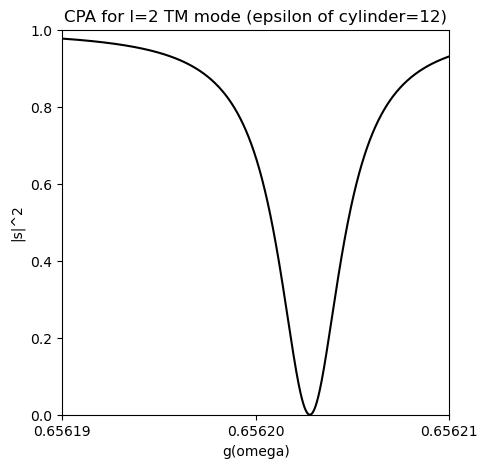

In [65]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("g(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 TM mode (epsilon of cylinder=12)");

### Now we do the same for TE modes for $l=1,2$

### From the TE plasmon dispersion, we expect $Z_s\approx -ix/2nc\varepsilon_0$

In [66]:
epsilon_real = 1
l = 1

M = 2000
N = 2000
Z_s_arr = -linspace(0.049, 0.052, M).reshape((M, 1)).repeat(N, 1)*1j
epsilon_imaginary = linspace(5.9, 6.2, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real + 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

In [67]:
numerator = jv(l, y) * hl2_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel2(l, x) 
denominator = jv(l, y) * hl1_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel1(l, x) 
s = numerator/denominator

In [68]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  6.681371720574345e-08


In [69]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [70]:
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", Z_s_arr[idxs])

CPA imepsilon:  6.098549274637319  and CPA g(omega):  (-0-0.05066733366683342j)


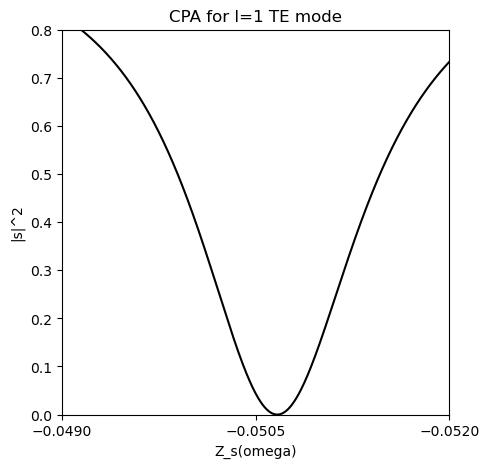

In [72]:
x1 = Z_s_arr[0, idxs[1]]/1j
x2 = Z_s_arr[-1, idxs[1]]/1j
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(Z_s_arr[:, idxs[1]]/1j, (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 0.8)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("Z_s(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 TE mode");

In [73]:
epsilon_real = 1
l = 1

M = 2000
N = 2000
Z_s_arr_imaginary = -linspace(0.049, 0.051, M).reshape((M, 1)).repeat(N, 1)*1j
Z_s_arr_real = -linspace(0.0003, 0.0005, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real 
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder
Z_s_arr = Z_s_arr_real + Z_s_arr_imaginary

In [74]:
numerator = jv(l, y) * hl2_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel2(l, x) 
denominator = jv(l, y) * hl1_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel1(l, x) 
s = numerator/denominator

In [75]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  1.1708536302422322e-07


In [76]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [77]:
print("CPA Z_s imaginary: ", Z_s_arr_imaginary[idxs].imag, " and CPA Z_s_arr real: ", Z_s_arr_real[idxs])

CPA Z_s imaginary:  -0.0506648324162081  and CPA Z_s_arr real:  -0.0003917458729364682


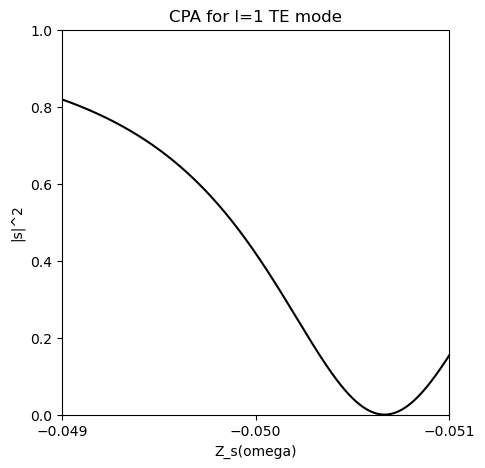

In [78]:
x1 = Z_s_arr_imaginary[0, idxs[1]]/1j
x2 = Z_s_arr_imaginary[-1, idxs[1]]/1j
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(Z_s_arr_imaginary[:, idxs[1]]/1j, (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("Z_s(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 TE mode");

In [79]:
epsilon_real = 12
l = 2

M = 2000
N = 2000
Z_s_arr = -linspace(0.025157, 0.025159, M).reshape((M, 1)).repeat(N, 1)*1j
epsilon_imaginary = linspace(0.0233, 0.0234, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real + 1j*epsilon_imaginary
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

In [80]:
numerator = jv(l, y) * hl2_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel2(l, x) 
denominator = jv(l, y) * hl1_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel1(l, x) 
s = numerator/denominator

In [81]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  4.348695828801877e-07


In [82]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [83]:
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", Z_s_arr[idxs])

CPA imepsilon:  0.02332631315657829  and CPA g(omega):  (-0-0.025157930465232615j)


### Note that the best value for $Z_s$ is indeed approximately $Z_s\approx -ix/(2\times n)=-i\times 0.1/(2\times 2)$

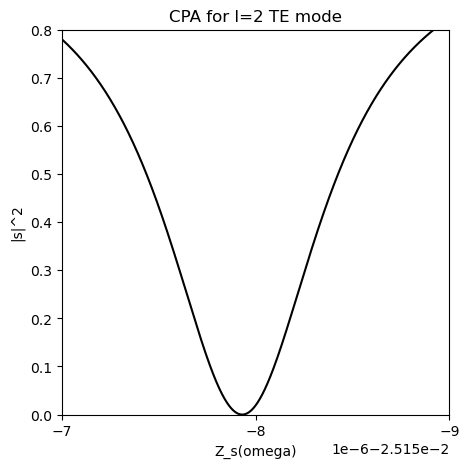

In [84]:
x1 = Z_s_arr[0, idxs[1]]/1j
x2 = Z_s_arr[-1, idxs[1]]/1j
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(Z_s_arr[:, idxs[1]]/1j, (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 0.8)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("Z_s(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 TE mode");

In [85]:
epsilon_real = 1
l = 2

M = 5000
N = 5000
Z_s_arr_imaginary = -linspace(0.02502, 0.02505, M).reshape((M, 1)).repeat(N, 1)*1j
Z_s_arr_real = -linspace(0.00000024, 0.00000025, N).reshape((1, N)).repeat(M, 0)
epsilon = epsilon_real 
x = 0.1 # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder
Z_s_arr = Z_s_arr_real + Z_s_arr_imaginary

In [86]:
numerator = jv(l, y) * hl2_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel2(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel2(l, x) 
denominator = jv(l, y) * hl1_prime(l, x) - sqrt(epsilon) * jvp(l, y, 1) * hankel1(l, x) - 1j*(1/Z_s_arr)*jv(l, y)* hankel1(l, x) 
s = numerator/denominator

In [87]:
print("Minimum |s|^2: ", min(abs(s)**2))

Minimum |s|^2:  3.04786874016929e-06


In [88]:
idxs = unravel_index(argmin(abs(s)**2), numerator.shape)

In [89]:
print("CPA Z_s imaginary: ", Z_s_arr_imaginary[idxs].imag, " and CPA Z_s_arr real: ", Z_s_arr_real[idxs])

CPA Z_s imaginary:  -0.025042114422884575  and CPA Z_s_arr real:  -2.450290058011602e-07


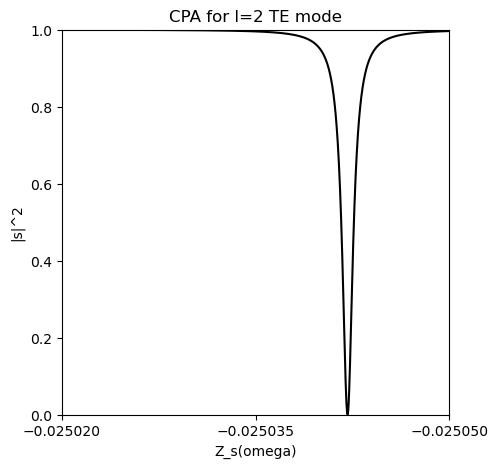

In [90]:
x1 = Z_s_arr_imaginary[0, idxs[1]]/1j
x2 = Z_s_arr_imaginary[-1, idxs[1]]/1j
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(Z_s_arr_imaginary[:, idxs[1]]/1j, (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("Z_s(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 TE mode");